In [1]:
import pandas as pd


file_path = r"C:\Users\emper\OneDrive\Desktop\immigration.csv"

try:
    data = pd.read_csv(file_path)
    print("파일이 성공적으로 로드되었습니다!")
    
    display(data.head())  
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 경로를 다시 확인하세요.")
except Exception as e:
    print(f"오류가 발생했습니다: {e}")

파일이 성공적으로 로드되었습니다!


,postmaterialism,institutional_trust,immigration_attitude,economic_dimension,sociocultural_dimension,age,income_level,religion,employment_group,gender,immigration_status,parent_immigration_status,education_level,postmaterialism_num,political_ideology_right,country,perception_economic_threat,national_identity
0,탈물질주의자,-0.975502,0.514981,0.519303,0.531405,0.481481,0.888889,종교 있음,취업자,남성,토착민,이민자 있음,1.647078,2,0.444444,20,4,4
1,혼합형,-0.253497,1.030417,0.519303,1.135233,0.490741,0.444444,종교 있음,취업자,남성,이민자,이민자 있음,1.647078,1,0.666667,20,2,2
2,탈물질주의자,-0.993027,-0.002835,0.423358,0.517410,0.555556,-0.333333,종교 있음,취업자,남성,이민자,이민자 있음,0.238055,2,0.777778,20,5,4
3,탈물질주의자,0.310089,0.884436,0.645718,1.193314,0.546296,0.333333,종교 있음,실업자,남성,이민자,이민자 있음,-0.231620,2,0.555556,20,2,4
4,탈물질주의자,0.224348,1.170010,0.007664,1.193314,0.407407,1.000000,종교 있음,실업자,남성,이민자,이민자 있음,1.647078,2,0.444444,20,2,3


In [6]:
import pandas as pd
import numpy as np
import networkx as nx
from dowhy import gcm
from dowhy.gcm import EmpiricalDistribution, AdditiveNoiseModel
from dowhy.gcm.ml import create_linear_regressor

# 0. 시드 고정
np.random.seed(42)

# 1. 데이터 
data = pd.read_csv(r"C:\Users\emper\OneDrive\Desktop\immigration.csv")

# 2. 변수 매핑 및 결측치 처리
filtered_data = data.copy()
filtered_data['postmaterialism_num'] = filtered_data['postmaterialism'].map({
    '물질주의자': 0, '혼합형': 1, '탈물질주의자': 2
})

filtered_data = filtered_data.dropna(subset=[
    'postmaterialism_num', 'institutional_trust', 'immigration_attitude',
    'economic_dimension', 'sociocultural_dimension',
    'age', 'income_level', 'religion', 'employment_group', 'gender',
    'immigration_status', 'parent_immigration_status', 'education_level',
    'political_ideology_right',
    'perception_economic_threat',         
    'national_identity'                  
])

# 3. 분석 변수 지정
target_variables = {
    "모델1(이민에 대한 태도)": "immigration_attitude",
    "모델2(경제적차원)": "economic_dimension",
    "모델3(사회문화차원)": "sociocultural_dimension"
}

control_vars = [
    'age', 'income_level', 'religion', 'employment_group', 'gender',
    'immigration_status', 'parent_immigration_status', 'education_level',
    'political_ideology_right',
    'perception_economic_threat',         
    'national_identity'                 
]

# 4. 조절효과 함수 정의
def moderation_effect_profile(causal_model, filtered_data, target, trust_values=None):
    """
    institutional_trust의 값을 여러 수준(예: 하위 10%~상위 90%)으로 고정하여
    postmaterialism_num의 효과(ATE)가 달라지는지 확인.
    """
    if trust_values is None:
        # 하위 10%, 중앙값, 상위 90%
        trust_values = [
            np.percentile(filtered_data['institutional_trust'], 10),
            np.percentile(filtered_data['institutional_trust'], 50),
            np.percentile(filtered_data['institutional_trust'], 90),
        ]

    min_val = int(filtered_data['postmaterialism_num'].min())
    max_val = int(filtered_data['postmaterialism_num'].max())

    print(f"\n[조절효과] '{target}'에서 institutional_trust 값에 따른 postmaterialism_num의 ATE 변화")
    for v in trust_values:
        att_min = gcm.interventional_samples(
            causal_model, {'postmaterialism_num': lambda x: min_val,
                           'institutional_trust': lambda x: v},
            num_samples_to_draw=len(filtered_data)
        )[target].mean()
        att_max = gcm.interventional_samples(
            causal_model, {'postmaterialism_num': lambda x: max_val,
                           'institutional_trust': lambda x: v},
            num_samples_to_draw=len(filtered_data)
        )[target].mean()
        ate = (att_max - att_min) / (max_val - min_val)
        print(f"  - 제도적신뢰 {v:.2f}에서 postmaterialism_num 1단위 증가 효과: {ate:.4f}")

# 5. 전체 분석 및 moderation 효과 출력
for model_name, target in target_variables.items():
    print(f"\n==== {model_name} : 종속변수 = {target} ====")
    graph = nx.DiGraph([
        ('postmaterialism_num', 'institutional_trust'),
        ('institutional_trust', target),
        ('postmaterialism_num', target),
        *[(ctrl, 'institutional_trust') for ctrl in control_vars],
        *[(ctrl, target) for ctrl in control_vars]
    ])

    causal_model = gcm.ProbabilisticCausalModel(graph)
    causal_model.set_causal_mechanism('postmaterialism_num', EmpiricalDistribution())
    causal_model.set_causal_mechanism('institutional_trust', AdditiveNoiseModel(create_linear_regressor()))
    causal_model.set_causal_mechanism(target, AdditiveNoiseModel(create_linear_regressor()))
    for ctrl in control_vars:
        causal_model.set_causal_mechanism(ctrl, EmpiricalDistribution())

    gcm.fit(causal_model, filtered_data)

    min_val = int(filtered_data['postmaterialism_num'].min())
    max_val = int(filtered_data['postmaterialism_num'].max())

    # 전체효과(ATE)
    mean_att_min = gcm.interventional_samples(
        causal_model, {'postmaterialism_num': lambda x: min_val},
        num_samples_to_draw=len(filtered_data)
    )[target].mean()
    mean_att_max = gcm.interventional_samples(
        causal_model, {'postmaterialism_num': lambda x: max_val},
        num_samples_to_draw=len(filtered_data)
    )[target].mean()
    ace_per_unit = (mean_att_max - mean_att_min) / (max_val - min_val)

    print(f"[전체효과] postmaterialism {min_val}→{max_val} {target} 평균 변화: {mean_att_max - mean_att_min:.4f}")
    print(f"[전체효과] postmaterialism 1단위 증가시 {target} 변화량: {ace_per_unit:.4f}")

    # 직접효과
    mean_trust = filtered_data['institutional_trust'].mean()
    direct_att_min = gcm.interventional_samples(
        causal_model, {'postmaterialism_num': lambda x: min_val, 'institutional_trust': lambda x: mean_trust},
        num_samples_to_draw=len(filtered_data)
    )[target].mean()
    direct_att_max = gcm.interventional_samples(
        causal_model, {'postmaterialism_num': lambda x: max_val, 'institutional_trust': lambda x: mean_trust},
        num_samples_to_draw=len(filtered_data)
    )[target].mean()
    direct_effect_per_unit = (direct_att_max - direct_att_min) / (max_val - min_val)

    print(f"[직접효과] postmaterialism {min_val}→{max_val} {target} 평균 변화: {direct_att_max - direct_att_min:.4f}")
    print(f"[직접효과] postmaterialism 1단위 증가시 {target} 변화량: {direct_effect_per_unit:.4f}")

    # 간접효과
    indirect_effect_per_unit = ace_per_unit - direct_effect_per_unit
    print(f"[간접효과] postmaterialism 1단위 증가시 {target} 변화량: {indirect_effect_per_unit:.4f}")

    # 조절효과 프로파일 출력
    moderation_effect_profile(causal_model, filtered_data, target)


==== 모델1(이민에 대한 태도) : 종속변수 = immigration_attitude ====


Fitting causal mechanism of node national_identity: 100%|█| 14/14 [


[전체효과] postmaterialism 0→2 immigration_attitude 평균 변화: 0.1129
[전체효과] postmaterialism 1단위 증가시 immigration_attitude 변화량: 0.0564
[직접효과] postmaterialism 0→2 immigration_attitude 평균 변화: 0.1222
[직접효과] postmaterialism 1단위 증가시 immigration_attitude 변화량: 0.0611
[간접효과] postmaterialism 1단위 증가시 immigration_attitude 변화량: -0.0046

[조절효과] 'immigration_attitude'에서 institutional_trust 값에 따른 postmaterialism_num의 ATE 변화
  - 제도적신뢰 -1.13에서 postmaterialism_num 1단위 증가 효과: 0.0617
  - 제도적신뢰 -0.16에서 postmaterialism_num 1단위 증가 효과: 0.0593
  - 제도적신뢰 0.78에서 postmaterialism_num 1단위 증가 효과: 0.0599

==== 모델2(경제적차원) : 종속변수 = economic_dimension ====


Fitting causal mechanism of node national_identity: 100%|█| 14/14 [


[전체효과] postmaterialism 0→2 economic_dimension 평균 변화: 0.0091
[전체효과] postmaterialism 1단위 증가시 economic_dimension 변화량: 0.0045
[직접효과] postmaterialism 0→2 economic_dimension 평균 변화: 0.0121
[직접효과] postmaterialism 1단위 증가시 economic_dimension 변화량: 0.0061
[간접효과] postmaterialism 1단위 증가시 economic_dimension 변화량: -0.0015

[조절효과] 'economic_dimension'에서 institutional_trust 값에 따른 postmaterialism_num의 ATE 변화
  - 제도적신뢰 -1.13에서 postmaterialism_num 1단위 증가 효과: 0.0063
  - 제도적신뢰 -0.16에서 postmaterialism_num 1단위 증가 효과: 0.0056
  - 제도적신뢰 0.78에서 postmaterialism_num 1단위 증가 효과: 0.0025

==== 모델3(사회문화차원) : 종속변수 = sociocultural_dimension ====


Fitting causal mechanism of node national_identity: 100%|█| 14/14 [


[전체효과] postmaterialism 0→2 sociocultural_dimension 평균 변화: 0.1250
[전체효과] postmaterialism 1단위 증가시 sociocultural_dimension 변화량: 0.0625
[직접효과] postmaterialism 0→2 sociocultural_dimension 평균 변화: 0.1273
[직접효과] postmaterialism 1단위 증가시 sociocultural_dimension 변화량: 0.0637
[간접효과] postmaterialism 1단위 증가시 sociocultural_dimension 변화량: -0.0012

[조절효과] 'sociocultural_dimension'에서 institutional_trust 값에 따른 postmaterialism_num의 ATE 변화
  - 제도적신뢰 -1.13에서 postmaterialism_num 1단위 증가 효과: 0.0636
  - 제도적신뢰 -0.16에서 postmaterialism_num 1단위 증가 효과: 0.0646
  - 제도적신뢰 0.78에서 postmaterialism_num 1단위 증가 효과: 0.0648



==== Model 1 (Attitude to Immigration) : Outcome variable = immigration_attitude ====


Fitting causal mechanism of node national_identity: 100%|█| 14/14 [


[Total Effect] postmaterialism 0→2 change in immigration_attitude (mean): 0.1129
[Total Effect] Change in immigration_attitude per 1 unit increase of postmaterialism: 0.0564
[Direct Effect] postmaterialism 0→2 change in immigration_attitude (mean): 0.1222
[Direct Effect] Change in immigration_attitude per 1 unit increase of postmaterialism (holding trust fixed): 0.0611
[Indirect Effect] Change in immigration_attitude per 1 unit increase of postmaterialism (mediated): -0.0046

[Moderation Effect] Change in ATE of postmaterialism_num at different levels of institutional_trust for 'immigration_attitude'
  - At institutional_trust -1.13, effect of 1 unit increase in postmaterialism_num: 0.0617
  - At institutional_trust -0.16, effect of 1 unit increase in postmaterialism_num: 0.0593
  - At institutional_trust 0.78, effect of 1 unit increase in postmaterialism_num: 0.0599


Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identi

[ATE Confidence Interval] 95% CI: [0.0451, 0.0663] (Bootstrap mean: 0.0556)


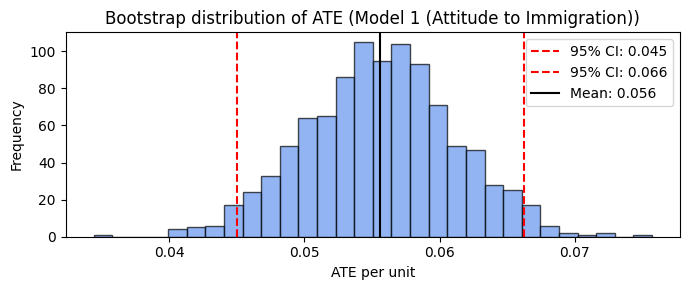


==== Model 2 (Economic Dimension) : Outcome variable = economic_dimension ====


Fitting causal mechanism of node national_identity: 100%|█| 14/14 [


[Total Effect] postmaterialism 0→2 change in economic_dimension (mean): 0.0073
[Total Effect] Change in economic_dimension per 1 unit increase of postmaterialism: 0.0036
[Direct Effect] postmaterialism 0→2 change in economic_dimension (mean): 0.0134
[Direct Effect] Change in economic_dimension per 1 unit increase of postmaterialism (holding trust fixed): 0.0067
[Indirect Effect] Change in economic_dimension per 1 unit increase of postmaterialism (mediated): -0.0031

[Moderation Effect] Change in ATE of postmaterialism_num at different levels of institutional_trust for 'economic_dimension'
  - At institutional_trust -1.13, effect of 1 unit increase in postmaterialism_num: 0.0055
  - At institutional_trust -0.16, effect of 1 unit increase in postmaterialism_num: 0.0077
  - At institutional_trust 0.78, effect of 1 unit increase in postmaterialism_num: 0.0052


Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identi

[ATE Confidence Interval] 95% CI: [-0.0052, 0.0119] (Bootstrap mean: 0.0035)


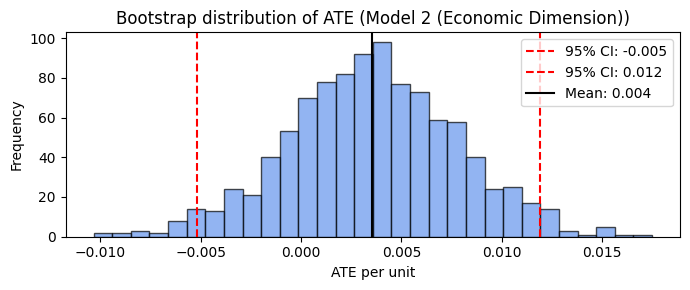


==== Model 3 (Sociocultural Dimension) : Outcome variable = sociocultural_dimension ====


Fitting causal mechanism of node national_identity: 100%|█| 14/14 [


[Total Effect] postmaterialism 0→2 change in sociocultural_dimension (mean): 0.1177
[Total Effect] Change in sociocultural_dimension per 1 unit increase of postmaterialism: 0.0589
[Direct Effect] postmaterialism 0→2 change in sociocultural_dimension (mean): 0.1205
[Direct Effect] Change in sociocultural_dimension per 1 unit increase of postmaterialism (holding trust fixed): 0.0602
[Indirect Effect] Change in sociocultural_dimension per 1 unit increase of postmaterialism (mediated): -0.0014

[Moderation Effect] Change in ATE of postmaterialism_num at different levels of institutional_trust for 'sociocultural_dimension'
  - At institutional_trust -1.13, effect of 1 unit increase in postmaterialism_num: 0.0610
  - At institutional_trust -0.16, effect of 1 unit increase in postmaterialism_num: 0.0588
  - At institutional_trust 0.78, effect of 1 unit increase in postmaterialism_num: 0.0638


Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identity: 100%|█| 14/14 [
Fitting causal mechanism of node national_identi

[ATE Confidence Interval] 95% CI: [0.0473, 0.0688] (Bootstrap mean: 0.0585)


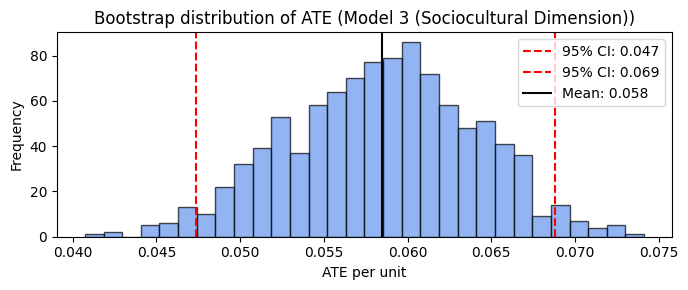

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from dowhy import gcm
from dowhy.gcm import EmpiricalDistribution, AdditiveNoiseModel
from dowhy.gcm.ml import create_linear_regressor

try:
    import arviz as az
except ImportError:
    az = None

# 0. Fix random seed
np.random.seed(42)

# 1. Load data
data = pd.read_csv(r"C:\Users\emper\OneDrive\Desktop\immigration.csv")

# 2. Variable mapping and missing value handling
filtered_data = data.copy()
filtered_data['postmaterialism_num'] = filtered_data['postmaterialism'].map({
    '물질주의자': 0, '혼합형': 1, '탈물질주의자': 2
})

filtered_data = filtered_data.dropna(subset=[
    'postmaterialism_num', 'institutional_trust', 'immigration_attitude',
    'economic_dimension', 'sociocultural_dimension',
    'age', 'income_level', 'religion', 'employment_group', 'gender',
    'immigration_status', 'parent_immigration_status', 'education_level',
    'political_ideology_right',
    'perception_economic_threat',
    'national_identity'
])

# 3. Analysis variables
target_variables = {
    "Model 1 (Attitude to Immigration)": "immigration_attitude",
    "Model 2 (Economic Dimension)": "economic_dimension",
    "Model 3 (Sociocultural Dimension)": "sociocultural_dimension"
}

control_vars = [
    'age', 'income_level', 'religion', 'employment_group', 'gender',
    'immigration_status', 'parent_immigration_status', 'education_level',
    'political_ideology_right',
    'perception_economic_threat',
    'national_identity'
]

# 4. Moderation effect function
def moderation_effect_profile(causal_model, filtered_data, target, trust_values=None):
    if trust_values is None:
        trust_values = [
            np.percentile(filtered_data['institutional_trust'], 10),
            np.percentile(filtered_data['institutional_trust'], 50),
            np.percentile(filtered_data['institutional_trust'], 90),
        ]

    min_val = int(filtered_data['postmaterialism_num'].min())
    max_val = int(filtered_data['postmaterialism_num'].max())

    print(f"\n[Moderation Effect] Change in ATE of postmaterialism_num at different levels of institutional_trust for '{target}'")
    for v in trust_values:
        att_min = gcm.interventional_samples(
            causal_model, {'postmaterialism_num': lambda x: min_val,
                           'institutional_trust': lambda x: v},
            num_samples_to_draw=len(filtered_data)
        )[target].mean()
        att_max = gcm.interventional_samples(
            causal_model, {'postmaterialism_num': lambda x: max_val,
                           'institutional_trust': lambda x: v},
            num_samples_to_draw=len(filtered_data)
        )[target].mean()
        ate = (att_max - att_min) / (max_val - min_val)
        print(f"  - At institutional_trust {v:.2f}, effect of 1 unit increase in postmaterialism_num: {ate:.4f}")

# 5. Main analysis with bootstrap ATE CI
n_bootstrap = 1000  # Bootstrap sampling 1000 times

for model_name, target in target_variables.items():
    print(f"\n==== {model_name} : Outcome variable = {target} ====")
    graph = nx.DiGraph([
        ('postmaterialism_num', 'institutional_trust'),
        ('institutional_trust', target),
        ('postmaterialism_num', target),
        *[(ctrl, 'institutional_trust') for ctrl in control_vars],
        *[(ctrl, target) for ctrl in control_vars]
    ])

    causal_model = gcm.ProbabilisticCausalModel(graph)
    causal_model.set_causal_mechanism('postmaterialism_num', EmpiricalDistribution())
    causal_model.set_causal_mechanism('institutional_trust', AdditiveNoiseModel(create_linear_regressor()))
    causal_model.set_causal_mechanism(target, AdditiveNoiseModel(create_linear_regressor()))
    for ctrl in control_vars:
        causal_model.set_causal_mechanism(ctrl, EmpiricalDistribution())

    gcm.fit(causal_model, filtered_data)

    min_val = int(filtered_data['postmaterialism_num'].min())
    max_val = int(filtered_data['postmaterialism_num'].max())

    # Total (ATE)
    mean_att_min = gcm.interventional_samples(
        causal_model, {'postmaterialism_num': lambda x: min_val},
        num_samples_to_draw=len(filtered_data)
    )[target].mean()
    mean_att_max = gcm.interventional_samples(
        causal_model, {'postmaterialism_num': lambda x: max_val},
        num_samples_to_draw=len(filtered_data)
    )[target].mean()
    ace_per_unit = (mean_att_max - mean_att_min) / (max_val - min_val)

    print(f"[Total Effect] postmaterialism {min_val}→{max_val} change in {target} (mean): {mean_att_max - mean_att_min:.4f}")
    print(f"[Total Effect] Change in {target} per 1 unit increase of postmaterialism: {ace_per_unit:.4f}")

    # Direct effect
    mean_trust = filtered_data['institutional_trust'].mean()
    direct_att_min = gcm.interventional_samples(
        causal_model, {'postmaterialism_num': lambda x: min_val, 'institutional_trust': lambda x: mean_trust},
        num_samples_to_draw=len(filtered_data)
    )[target].mean()
    direct_att_max = gcm.interventional_samples(
        causal_model, {'postmaterialism_num': lambda x: max_val, 'institutional_trust': lambda x: mean_trust},
        num_samples_to_draw=len(filtered_data)
    )[target].mean()
    direct_effect_per_unit = (direct_att_max - direct_att_min) / (max_val - min_val)

    print(f"[Direct Effect] postmaterialism {min_val}→{max_val} change in {target} (mean): {direct_att_max - direct_att_min:.4f}")
    print(f"[Direct Effect] Change in {target} per 1 unit increase of postmaterialism (holding trust fixed): {direct_effect_per_unit:.4f}")

    # Indirect effect
    indirect_effect_per_unit = ace_per_unit - direct_effect_per_unit
    print(f"[Indirect Effect] Change in {target} per 1 unit increase of postmaterialism (mediated): {indirect_effect_per_unit:.4f}")

    # Moderation effect profile
    moderation_effect_profile(causal_model, filtered_data, target)

    # ===== Bootstrap confidence interval for ATE =====
    ate_bootstrap = []
    for i in range(n_bootstrap):
        boot_idx = np.random.choice(len(filtered_data), size=len(filtered_data), replace=True)
        boot_data = filtered_data.iloc[boot_idx]

        boot_model = gcm.ProbabilisticCausalModel(graph)
        boot_model.set_causal_mechanism('postmaterialism_num', EmpiricalDistribution())
        boot_model.set_causal_mechanism('institutional_trust', AdditiveNoiseModel(create_linear_regressor()))
        boot_model.set_causal_mechanism(target, AdditiveNoiseModel(create_linear_regressor()))
        for ctrl in control_vars:
            boot_model.set_causal_mechanism(ctrl, EmpiricalDistribution())
        gcm.fit(boot_model, boot_data)

        mean_min = gcm.interventional_samples(
            boot_model, {'postmaterialism_num': lambda x: min_val},
            num_samples_to_draw=len(boot_data)
        )[target].mean()
        mean_max = gcm.interventional_samples(
            boot_model, {'postmaterialism_num': lambda x: max_val},
            num_samples_to_draw=len(boot_data)
        )[target].mean()
        ate = (mean_max - mean_min) / (max_val - min_val)
        ate_bootstrap.append(ate)

    ate_bootstrap = np.array(ate_bootstrap)
    ci_lower = np.percentile(ate_bootstrap, 2.5)
    ci_upper = np.percentile(ate_bootstrap, 97.5)
    mean_ate = np.mean(ate_bootstrap)
    print(f"[ATE Confidence Interval] 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}] (Bootstrap mean: {mean_ate:.4f})")

    if az is not None:
        hdi = az.hdi(ate_bootstrap, hdi_prob=0.95)
        print(f"[ATE 95% HDI]: [{hdi[0]:.4f}, {hdi[1]:.4f}]")

    # Histogram visualization (in English)
    plt.figure(figsize=(7, 3))
    plt.hist(ate_bootstrap, bins=30, color="#6495ED", alpha=0.7, edgecolor="k")
    plt.axvline(ci_lower, color='red', linestyle='--', label=f'95% CI: {ci_lower:.3f}')
    plt.axvline(ci_upper, color='red', linestyle='--', label=f'95% CI: {ci_upper:.3f}')
    plt.axvline(mean_ate, color='black', linestyle='-', label=f'Mean: {mean_ate:.3f}')
    plt.title(f"Bootstrap distribution of ATE ({model_name})")
    plt.xlabel("ATE per unit")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

=== Model 1 (Immigration Attitude) ===


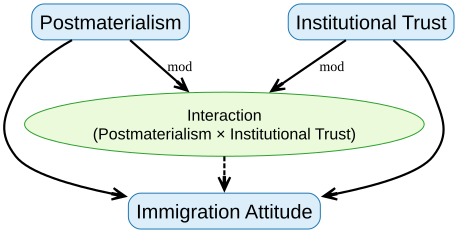

=== Model 2 (Economic Dimension) ===


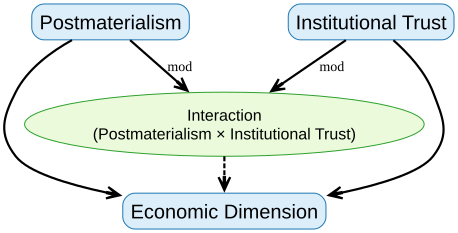

=== Model 3 (Sociocultural Dimension) ===


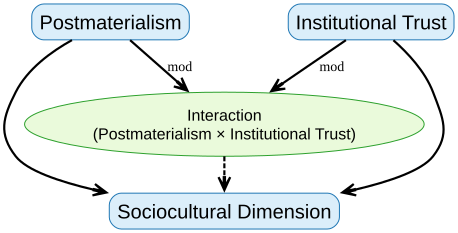

In [3]:
import graphviz

var_labels = {
    'postmaterialism': 'Postmaterialism',
    'institutional_trust': 'Institutional Trust',
    'immigration_attitude': 'Immigration Attitude',
    'economic_dimension': 'Economic Dimension',
    'sociocultural_dimension': 'Sociocultural Dimension',
    'interaction': 'Interaction\n(Postmaterialism × Institutional Trust)'
}

models = {
    "Model 1 (Immigration Attitude)": "immigration_attitude",
    "Model 2 (Economic Dimension)": "economic_dimension",
    "Model 3 (Sociocultural Dimension)": "sociocultural_dimension"
}

for model_name, target in models.items():
    dot = graphviz.Digraph(
        comment=model_name,
        format='png'
    )
    # Main nodes
    dot.node('postmaterialism', label=var_labels['postmaterialism'],
             shape='box', style='rounded,filled', color='#1f77b4', fillcolor='#dbeefa', fontsize='20', fontname='Arial')
    dot.node('institutional_trust', label=var_labels['institutional_trust'],
             shape='box', style='rounded,filled', color='#1f77b4', fillcolor='#dbeefa', fontsize='20', fontname='Arial')
    dot.node('interaction', label=var_labels['interaction'],
             shape='ellipse', style='filled', color='#2ca02c', fillcolor='#eafadb', fontsize='16', fontname='Arial')
    dot.node(target, label=var_labels[target],
             shape='box', style='rounded,filled', color='#1f77b4', fillcolor='#dbeefa', fontsize='20', fontname='Arial')

    # Edges
    dot.edge('postmaterialism', 'interaction', arrowhead='vee', arrowsize='1.3', penwidth='2.2', label='mod')
    dot.edge('institutional_trust', 'interaction', arrowhead='vee', arrowsize='1.3', penwidth='2.2', label='mod')
    dot.edge('postmaterialism', target, arrowhead='vee', arrowsize='1.3', penwidth='2.2')
    dot.edge('institutional_trust', target, arrowhead='vee', arrowsize='1.3', penwidth='2.2')
    dot.edge('interaction', target, arrowhead='vee', arrowsize='1.3', penwidth='2.2', style='dashed')

    print(f"=== {model_name} ===")
    display(dot)

=== Model 1 (Immigration Attitude) ===


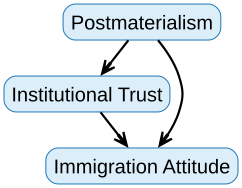

=== Model 2 (Economic Dimension) ===


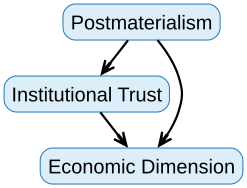

=== Model 3 (Sociocultural Dimension) ===


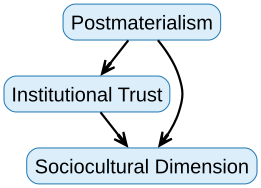

In [4]:
import graphviz

var_labels = {
    'postmaterialism': 'Postmaterialism',
    'institutional_trust': 'Institutional Trust',
    'immigration_attitude': 'Immigration Attitude',
    'economic_dimension': 'Economic Dimension',
    'sociocultural_dimension': 'Sociocultural Dimension',
}

models = {
    "Model 1 (Immigration Attitude)": "immigration_attitude",
    "Model 2 (Economic Dimension)": "economic_dimension",
    "Model 3 (Sociocultural Dimension)": "sociocultural_dimension"
}

for model_name, target in models.items():
    dot = graphviz.Digraph(
        comment=model_name,
        format='png',
        graph_attr={
            
        }
    )
    main_nodes = ['postmaterialism', 'institutional_trust', target]
    for node in main_nodes:
        dot.node(
            node,
            label=var_labels[node],
            shape='box',
            style='rounded,filled',
            color='#1f77b4',
            fillcolor='#dbeefa',
            fontsize='20',
            fontname='Arial'
        )
    dot.edge('postmaterialism', 'institutional_trust', arrowhead='vee', arrowsize='1.3', penwidth='2.2')
    dot.edge('institutional_trust', target, arrowhead='vee', arrowsize='1.3', penwidth='2.2')
    dot.edge('postmaterialism', target, arrowhead='vee', arrowsize='1.3', penwidth='2.2')

    print(f"=== {model_name} ===")
    display(dot)

=== Model 1 (Immigration Attitude) ===


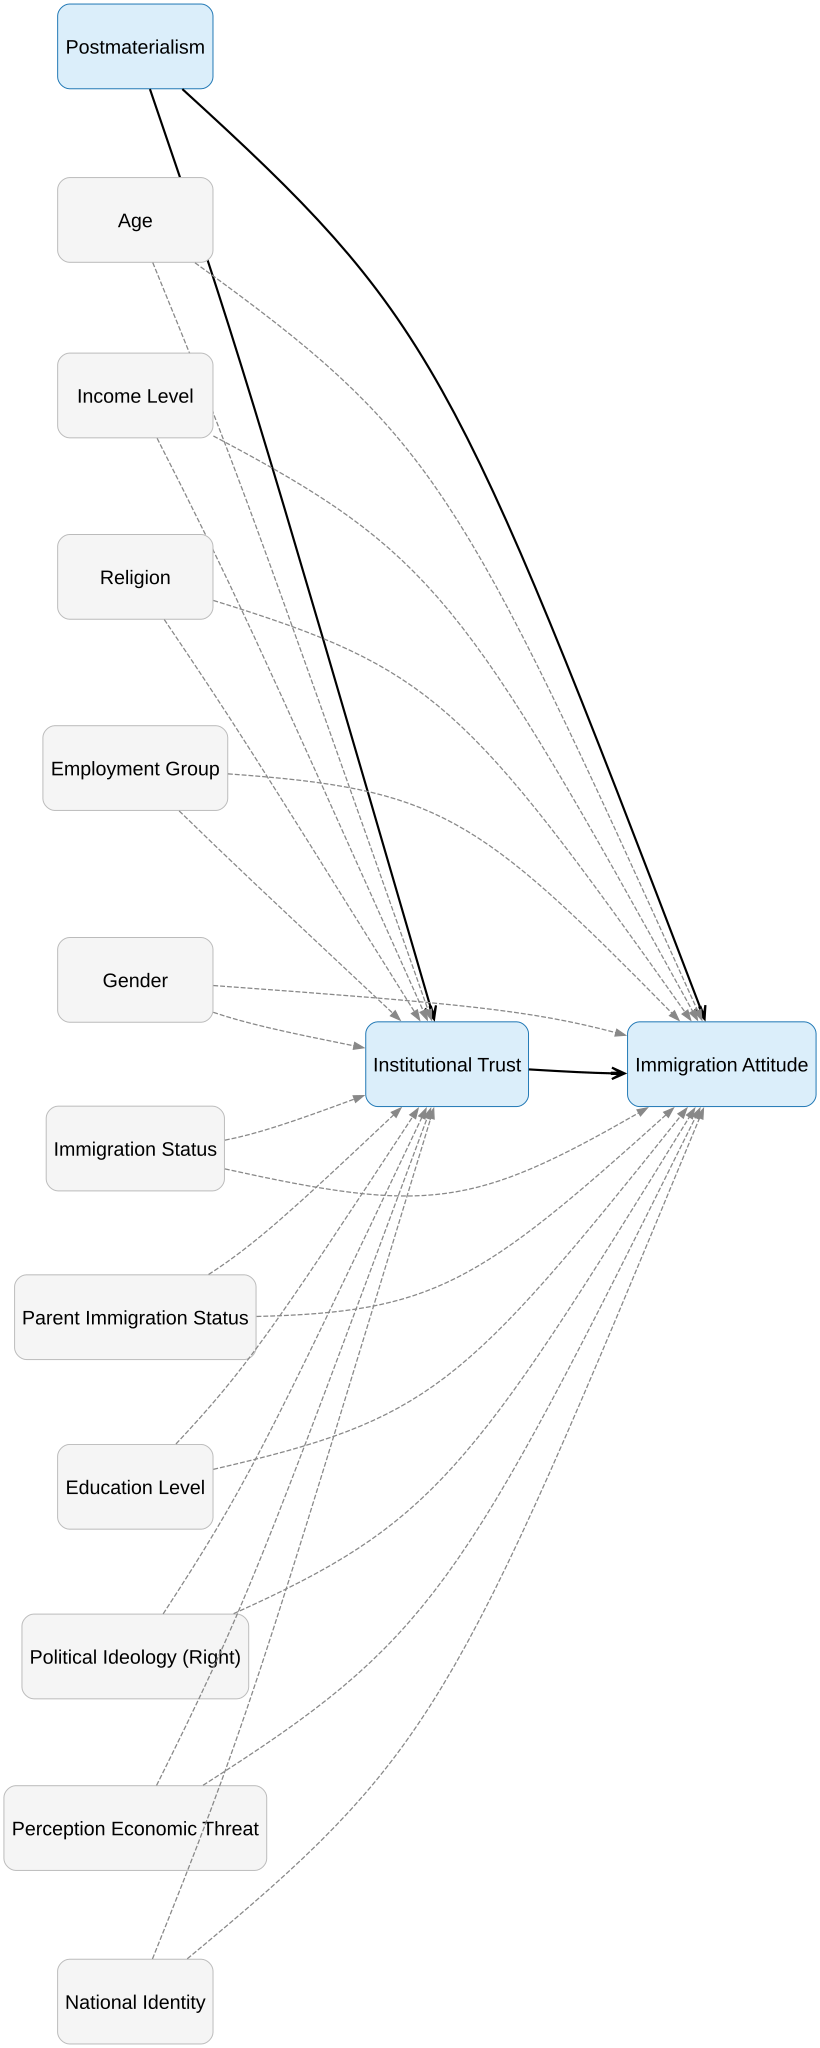

=== Model 2 (Economic Dimension) ===


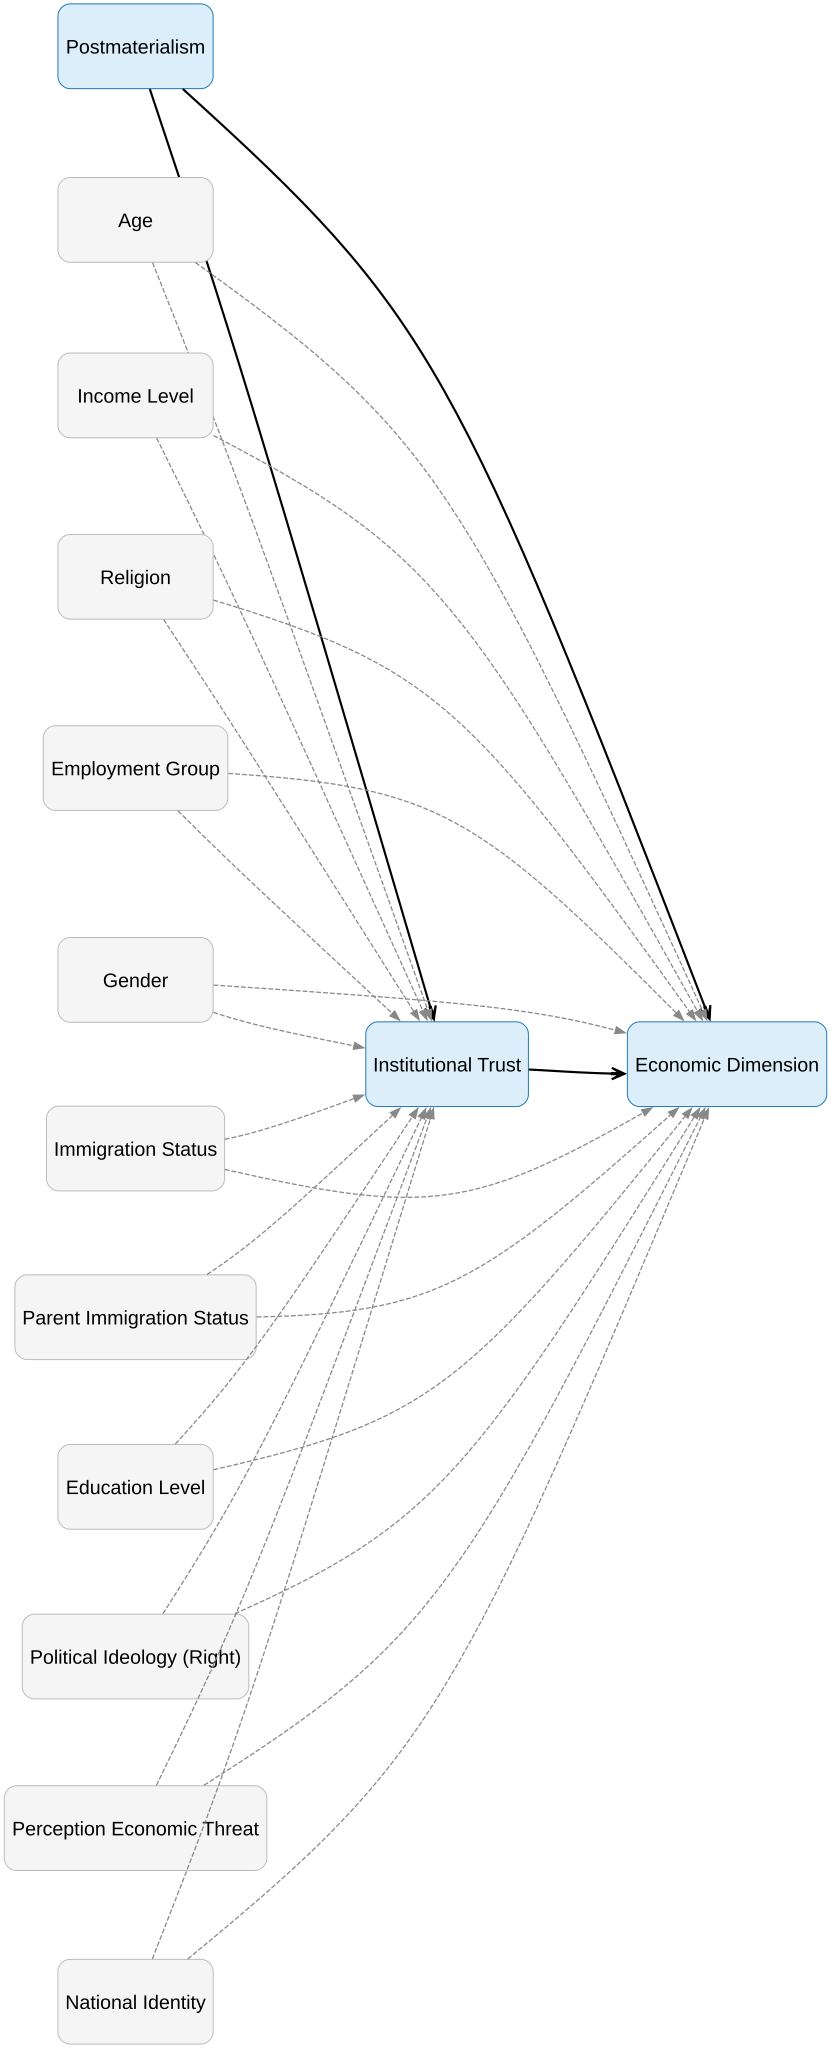

=== Model 3 (Sociocultural Dimension) ===


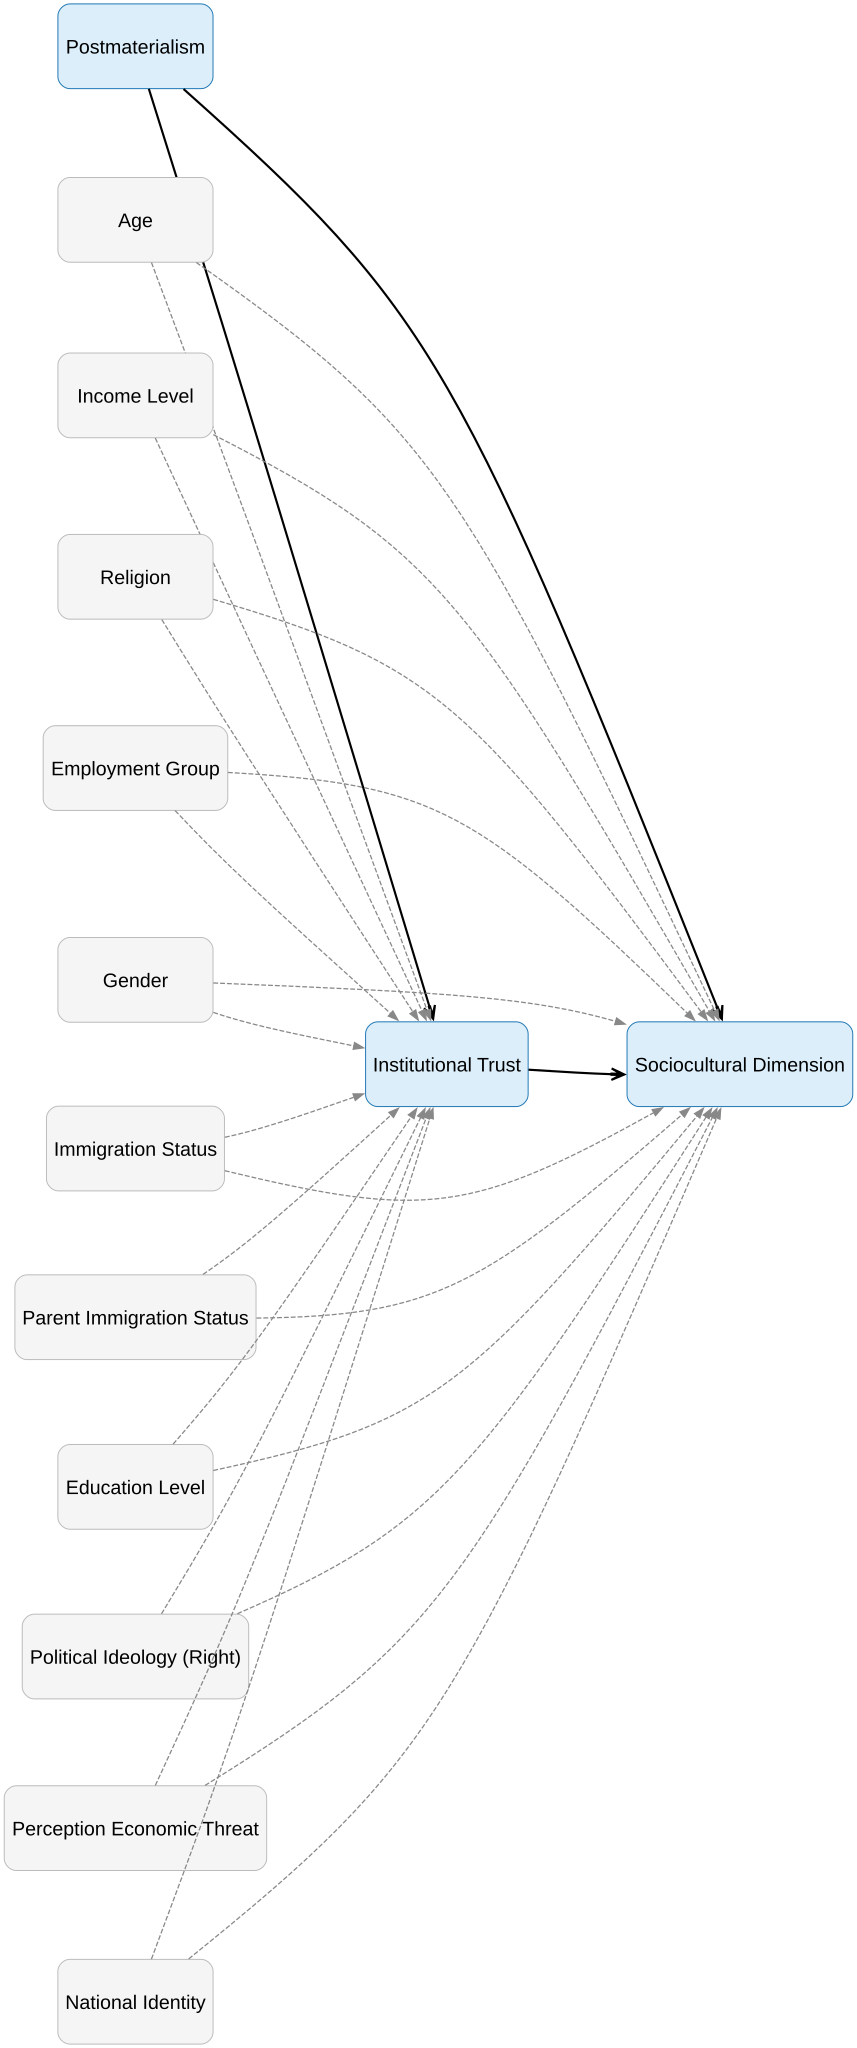

In [3]:
import graphviz

var_labels = {
    'postmaterialism': 'Postmaterialism',
    'institutional_trust': 'Institutional Trust',
    'immigration_attitude': 'Immigration Attitude',
    'economic_dimension': 'Economic Dimension',
    'sociocultural_dimension': 'Sociocultural Dimension',
    'age': 'Age',
    'income_level': 'Income Level',
    'religion': 'Religion',
    'employment_group': 'Employment Group',
    'gender': 'Gender',
    'immigration_status': 'Immigration Status',
    'parent_immigration_status': 'Parent Immigration Status',
    'education_level': 'Education Level',
    'political_ideology_right': 'Political Ideology (Right)',
    'perception_economic_threat': 'Perception Economic Threat',
    'national_identity': 'National Identity'
}

control_vars = [
    'age', 'income_level', 'religion', 'employment_group', 'gender',
    'immigration_status', 'parent_immigration_status', 'education_level',
    'political_ideology_right', 'perception_economic_threat', 'national_identity'
]

models = {
    "Model 1 (Immigration Attitude)": "immigration_attitude",
    "Model 2 (Economic Dimension)": "economic_dimension",
    "Model 3 (Sociocultural Dimension)": "sociocultural_dimension"
}

for model_name, target in models.items():
    dot = graphviz.Digraph(
        comment=model_name,
        format='png',
        graph_attr={
            "rankdir": "LR",
            "splines": "curved",
            "nodesep": "1.2",
            "ranksep": "1.4"
        }
    )
    # Main nodes
    main_nodes = ['postmaterialism', 'institutional_trust', target]
    for node in main_nodes + control_vars:
        dot.node(
            node,
            label=var_labels[node],
            shape='box',
            style='rounded,filled',
            color='#1f77b4' if node in main_nodes else '#bbbbbb',
            fillcolor='#dbeefa' if node in main_nodes else '#f5f5f5',
            fontsize='20',
            fontname='Arial',
            width='2.2',
            height='1.2',
            fixedsize='false'
        )
    # Main edges
    dot.edge('postmaterialism', 'institutional_trust', arrowhead='vee', arrowsize='1.3', penwidth='2.2')
    dot.edge('institutional_trust', target, arrowhead='vee', arrowsize='1.3', penwidth='2.2')
    dot.edge('postmaterialism', target, arrowhead='vee', arrowsize='1.3', penwidth='2.2')
    # Control variable edges
    for ctrl in control_vars:
        dot.edge(ctrl, 'institutional_trust', style='dashed', color='#888888', penwidth='1.3')
        dot.edge(ctrl, target, style='dashed', color='#888888', penwidth='1.3')

    print(f"=== {model_name} ===")
    display(dot)

In [4]:
import pandas as pd
import networkx as nx
from dowhy import CausalModel

# 1. Load data
file_path = r"C:\Users\emper\OneDrive\Desktop\immigration.csv"
df = pd.read_csv(file_path)

# 2. Preprocess data
df['postmaterialism'] = df['postmaterialism'].map({
    '물질주의자': 0, '혼합형': 1, '탈물질주의자': 2
})
df = df.dropna(subset=[
    'postmaterialism', 'institutional_trust', 'immigration_attitude',
    'age', 'income_level', 'religion', 'employment_group', 'gender',
    'immigration_status', 'parent_immigration_status', 'education_level',
    'political_ideology_right',            
    'perception_economic_threat',          
    'national_identity'                    
])

# 3. Define DAG (for Model 1)
target = "immigration_attitude"
gml_graph = nx.DiGraph([
    ('postmaterialism', 'institutional_trust'),
    ('institutional_trust', target),
    ('postmaterialism', target),
    ('age', 'institutional_trust'), ('age', target),
    ('income_level', 'institutional_trust'), ('income_level', target),
    ('religion', 'institutional_trust'), ('religion', target),
    ('employment_group', 'institutional_trust'), ('employment_group', target),
    ('gender', 'institutional_trust'), ('gender', target),
    ('immigration_status', 'institutional_trust'), ('immigration_status', target),
    ('parent_immigration_status', 'institutional_trust'), ('parent_immigration_status', target),
    ('education_level', 'institutional_trust'), ('education_level', target),
    ('political_ideology_right', 'institutional_trust'), ('political_ideology_right', target),
    ('perception_economic_threat', 'institutional_trust'), ('perception_economic_threat', target), 
    ('national_identity', 'institutional_trust'), ('national_identity', target)                  
])

# 4. Create CausalModel
model = CausalModel(
    data=df,
    treatment='institutional_trust',
    outcome=target,
    graph=gml_graph
)

# 5. Identify estimand
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print("Identified estimand:")
print(identified_estimand)

# 6. Estimate causal effect
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    test_significance=True
)
print("Causal effect estimate:")
print(estimate)

# 7. Run refuters
refuter_methods = [
    "placebo_treatment_refuter",
    "data_subset_refuter",
    "random_common_cause",
    "bootstrap_refuter"
]
for method in refuter_methods:
    print(f"\n--- Refuter: {method} ---")
    try:
        if method == "bootstrap_refuter":
            refute_result = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method, num_simulations=1000
            )
        else:
            refute_result = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method
            )
        print(refute_result)
    except Exception as e:
        print(f"Error in refuter '{method}': {e}")

Identified estimand:
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                       ↪
─────────────────────(E[immigration_attitude|gender,education_lev ↪
d[institutionalₜᵣᵤₛₜ]                                             ↪

↪                                                                 ↪
↪ el,national_identity,religion,income_level,perception_economic_ ↪
↪                                                                 ↪

↪                                                                 ↪
↪ threat,parent_immigration_status,political_ideology_right,immig ↪
↪                                                                 ↪

↪                                                     
↪ ration_status,age,postmaterialism,employment_group])
↪                                                     
Estimand assumption 1, Unconfoundedness: If U→{institutional_trust} and U→immigration_atti

C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]


Causal effect estimate:
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                       ↪
─────────────────────(E[immigration_attitude|gender,education_lev ↪
d[institutionalₜᵣᵤₛₜ]                                             ↪

↪                                                                 ↪
↪ el,national_identity,religion,income_level,perception_economic_ ↪
↪                                                                 ↪

↪                                                                 ↪
↪ threat,parent_immigration_status,political_ideology_right,immig ↪
↪                                                                 ↪

↪                                                     
↪ ration_status,age,postmaterialism,employment_group])
↪                                                     
Estimand assumption 1, Unconfoundedness

C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation

Refute: Use a Placebo Treatment
Estimated effect:0.1369144246111949
New effect:-2.7755575615628914e-17
p value:0.0


--- Refuter: data_subset_refuter ---


...

C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation

Refute: Add a random common cause
Estimated effect:0.1369144246111949
New effect:0.13691451895737197
p value:0.96


--- Refuter: bootstrap_refuter ---


C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation

Refute: Bootstrap Sample Dataset
Estimated effect:0.1369144246111949
New effect:0.1371711016438768
p value:0.962



C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]


In [5]:
import pandas as pd
import networkx as nx
from dowhy import CausalModel

# 1. Load data
file_path = r"C:\Users\emper\OneDrive\Desktop\immigration.csv"
df = pd.read_csv(file_path)

# 2. Preprocess data
df['postmaterialism'] = df['postmaterialism'].map({
    '물질주의자': 0, '혼합형': 1, '탈물질주의자': 2
})
df = df.dropna(subset=[
    'postmaterialism', 'institutional_trust', 'economic_dimension',
    'age', 'income_level', 'religion', 'employment_group', 'gender',
    'immigration_status', 'parent_immigration_status', 'education_level',
    'political_ideology_right',
    'perception_economic_threat',
    'national_identity'
])

# 3. Define DAG (for Model 2)
target = "economic_dimension"
gml_graph = nx.DiGraph([
    ('postmaterialism', 'institutional_trust'),
    ('institutional_trust', target),
    ('postmaterialism', target),
    ('age', 'institutional_trust'), ('age', target),
    ('income_level', 'institutional_trust'), ('income_level', target),
    ('religion', 'institutional_trust'), ('religion', target),
    ('employment_group', 'institutional_trust'), ('employment_group', target),
    ('gender', 'institutional_trust'), ('gender', target),
    ('immigration_status', 'institutional_trust'), ('immigration_status', target),
    ('parent_immigration_status', 'institutional_trust'), ('parent_immigration_status', target),
    ('education_level', 'institutional_trust'), ('education_level', target),
    ('political_ideology_right', 'institutional_trust'), ('political_ideology_right', target),
    ('perception_economic_threat', 'institutional_trust'), ('perception_economic_threat', target),
    ('national_identity', 'institutional_trust'), ('national_identity', target)
])

# 4. Create CausalModel
model = CausalModel(
    data=df,
    treatment='institutional_trust',
    outcome=target,
    graph=gml_graph
)

# 5. Identify estimand
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print("Identified estimand:")
print(identified_estimand)

# 6. Estimate causal effect
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    test_significance=True
)
print("Causal effect estimate:")
print(estimate)

# 7. Run refuters
refuter_methods = [
    "placebo_treatment_refuter",
    "data_subset_refuter",
    "random_common_cause",
    "bootstrap_refuter"
]
for method in refuter_methods:
    print(f"\n--- Refuter: {method} ---")
    try:
        if method == "bootstrap_refuter":
            refute_result = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method, num_simulations=1000
            )
        else:
            refute_result = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method
            )
        print(refute_result)
    except Exception as e:
        print(f"Error in refuter '{method}': {e}")

Identified estimand:
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                       ↪
─────────────────────(E[economic_dimension|gender,education_level ↪
d[institutionalₜᵣᵤₛₜ]                                             ↪

↪                                                                 ↪
↪ ,national_identity,religion,income_level,perception_economic_th ↪
↪                                                                 ↪

↪                                                                 ↪
↪ reat,parent_immigration_status,political_ideology_right,immigra ↪
↪                                                                 ↪

↪                                                   
↪ tion_status,age,postmaterialism,employment_group])
↪                                                   
Estimand assumption 1, Unconfoundedness: If U→{institutional_trust} and U→economic_dimension the

C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]


Causal effect estimate:
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                       ↪
─────────────────────(E[economic_dimension|gender,education_level ↪
d[institutionalₜᵣᵤₛₜ]                                             ↪

↪                                                                 ↪
↪ ,national_identity,religion,income_level,perception_economic_th ↪
↪                                                                 ↪

↪                                                                 ↪
↪ reat,parent_immigration_status,political_ideology_right,immigra ↪
↪                                                                 ↪

↪                                                   
↪ tion_status,age,postmaterialism,employment_group])
↪                                                   
Estimand assumption 1, Unconfoundedness: If U

C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation

Refute: Use a Placebo Treatment
Estimated effect:0.01856703705149032
New effect:-4.85722573273506e-17
p value:0.0


--- Refuter: data_subset_refuter ---


...

C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation

Refute: Add a random common cause
Estimated effect:0.01856703705149032
New effect:0.018563541473612218
p value:0.8


--- Refuter: bootstrap_refuter ---


C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation

Refute: Bootstrap Sample Dataset
Estimated effect:0.01856703705149032
New effect:0.018610909416357378
p value:0.956



C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]


In [6]:
import pandas as pd
import networkx as nx
from dowhy import CausalModel

# 1. Load data
file_path = r"C:\Users\emper\OneDrive\Desktop\immigration.csv"
df = pd.read_csv(file_path)

# 2. Preprocess data
df['postmaterialism'] = df['postmaterialism'].map({
    '물질주의자': 0, '혼합형': 1, '탈물질주의자': 2
})
df = df.dropna(subset=[
    'postmaterialism', 'institutional_trust', 'sociocultural_dimension',
    'age', 'income_level', 'religion', 'employment_group', 'gender',
    'immigration_status', 'parent_immigration_status', 'education_level',
    'political_ideology_right',
    'perception_economic_threat',
    'national_identity'
])

# 3. Define DAG (for Model 3)
target = "sociocultural_dimension"
gml_graph = nx.DiGraph([
    ('postmaterialism', 'institutional_trust'),
    ('institutional_trust', target),
    ('postmaterialism', target),
    ('age', 'institutional_trust'), ('age', target),
    ('income_level', 'institutional_trust'), ('income_level', target),
    ('religion', 'institutional_trust'), ('religion', target),
    ('employment_group', 'institutional_trust'), ('employment_group', target),
    ('gender', 'institutional_trust'), ('gender', target),
    ('immigration_status', 'institutional_trust'), ('immigration_status', target),
    ('parent_immigration_status', 'institutional_trust'), ('parent_immigration_status', target),
    ('education_level', 'institutional_trust'), ('education_level', target),
    ('political_ideology_right', 'institutional_trust'), ('political_ideology_right', target),
    ('perception_economic_threat', 'institutional_trust'), ('perception_economic_threat', target),
    ('national_identity', 'institutional_trust'), ('national_identity', target)
])

# 4. Create CausalModel
model = CausalModel(
    data=df,
    treatment='institutional_trust',
    outcome=target,
    graph=gml_graph
)

# 5. Identify estimand
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print("Identified estimand:")
print(identified_estimand)

# 6. Estimate causal effect
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    test_significance=True
)
print("Causal effect estimate:")
print(estimate)

# 7. Run refuters
refuter_methods = [
    "placebo_treatment_refuter",
    "data_subset_refuter",
    "random_common_cause",
    "bootstrap_refuter"
]
for method in refuter_methods:
    print(f"\n--- Refuter: {method} ---")
    try:
        if method == "bootstrap_refuter":
            refute_result = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method, num_simulations=1000
            )
        else:
            refute_result = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method
            )
        print(refute_result)
    except Exception as e:
        print(f"Error in refuter '{method}': {e}")

Identified estimand:
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                       ↪
─────────────────────(E[sociocultural_dimension|gender,education_ ↪
d[institutionalₜᵣᵤₛₜ]                                             ↪

↪                                                                 ↪
↪ level,national_identity,religion,income_level,perception_econom ↪
↪                                                                 ↪

↪                                                                 ↪
↪ ic_threat,parent_immigration_status,political_ideology_right,im ↪
↪                                                                 ↪

↪                                                        
↪ migration_status,age,postmaterialism,employment_group])
↪                                                        
Estimand assumption 1, Unconfoundedness: If U→{institutional_trust} and U→sociocu

C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]


Causal effect estimate:
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                       ↪
─────────────────────(E[sociocultural_dimension|gender,education_ ↪
d[institutionalₜᵣᵤₛₜ]                                             ↪

↪                                                                 ↪
↪ level,national_identity,religion,income_level,perception_econom ↪
↪                                                                 ↪

↪                                                                 ↪
↪ ic_threat,parent_immigration_status,political_ideology_right,im ↪
↪                                                                 ↪

↪                                                        
↪ migration_status,age,postmaterialism,employment_group])
↪                                                        
Estimand assumption 1, Unconfo

C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation

Refute: Use a Placebo Treatment
Estimated effect:0.14130704744188233
New effect:-4.163336342344337e-17
p value:0.0


--- Refuter: data_subset_refuter ---


...

C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation

Refute: Add a random common cause
Estimated effect:0.14130704744188233
New effect:0.1413053143208367
p value:1.0


--- Refuter: bootstrap_refuter ---


C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation

Refute: Bootstrap Sample Dataset
Estimated effect:0.14130704744188233
New effect:0.14138748816925126
p value:0.996



C:\Users\emper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dowhy\causal_estimators\regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
